# CatBoost Classification Model

**Module:** IT2011 - Artificial Intelligence and Machine Learning  
**Group ID:** 2026-Y2-S1-MET-18  
**Student ID:** IT25102123  
**Model:** CatBoost Classifier  

## Objective

The objective of this notebook is to build, tune, and evaluate a CatBoost classification model for predicting credit risk.

The target variable is `loan_status`:

- `0` = No Default
- `1` = Default

CatBoost is suitable for this dataset because it can handle both numerical and categorical features directly. It also performs well on structured/tabular datasets and reduces the need for extensive categorical encoding.

This notebook will:
1. Prepare the dataset for CatBoost.
2. Create training and testing datasets.
3. Train a baseline CatBoost model.
4. Train multiple CatBoost variants.
5. Perform hyperparameter tuning.
6. Evaluate the model using appropriate classification metrics.
7. Perform cross-validation.
8. Compare the different CatBoost variants.
9. Identify the best CatBoost configuration.
10. Discuss limitations and possible improvements.

In [2]:
# Cell 2: Import required libraries

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from catboost import CatBoostClassifier, Pool

RANDOM_STATE = 42

print("Libraries imported successfully.")

ModuleNotFoundError: No module named 'numpy'

In [1]:
%pip install numpy pandas matplotlib scikit-learn catboost

  Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.6-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached catboost-1.2.10-cp314-cp314-win_amd64.whl.metadata (1.5 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.1-cp314-cp314-win_amd64.whl.metadata (132 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Cell 2: Import required libraries

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from catboost import CatBoostClassifier, Pool

RANDOM_STATE = 42

print("Libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.


In [2]:
# Cell 3: Load the Credit Risk dataset

from pathlib import Path

# Find the project root automatically
current_path = Path.cwd().resolve()
PROJECT_ROOT = current_path

while PROJECT_ROOT.name != "2026-Y2-S1-MET-18" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

print("Project root:", PROJECT_ROOT)

# First, check whether a CSV already exists inside the project
processed_files = list((PROJECT_ROOT / "data" / "processed").glob("*.csv"))
raw_files = list((PROJECT_ROOT / "data" / "raw").glob("*.csv"))

if processed_files:
    DATA_PATH = processed_files[0]
    print("Using processed dataset:", DATA_PATH.name)

elif raw_files:
    DATA_PATH = raw_files[0]
    print("Using raw dataset:", DATA_PATH.name)

else:
    # If dataset is not stored locally, download the assigned dataset from Kaggle
    try:
        import kagglehub
    except ImportError:
        raise ImportError(
            "kagglehub is not installed. Run: %pip install kagglehub"
        )

    kaggle_path = Path(
        kagglehub.dataset_download("laotse/credit-risk-dataset")
    )

    csv_files = list(kaggle_path.glob("*.csv"))

    if not csv_files:
        raise FileNotFoundError("No CSV file found in the downloaded Kaggle dataset.")

    DATA_PATH = csv_files[0]

    print("Dataset downloaded from Kaggle.")
    print("Dataset file:", DATA_PATH.name)

# Load dataset
df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Project root: D:\2026-Y2-S1-MET-18


ImportError: kagglehub is not installed. Run: %pip install kagglehub

In [3]:
%pip install kagglehub

  Using cached kagglehub-1.0.2-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.37-py3-none-any.whl.metadata (13 kB)
  Using cached tqdm-4.70.1-py3-none-any.whl.metadata (57 kB)
  Using cached protobuf-7.36.2-cp310-abi3-win_amd64.whl.metadata (595 bytes)

   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Cell 3: Load the Credit Risk dataset

from pathlib import Path

# Find the project root automatically
current_path = Path.cwd().resolve()
PROJECT_ROOT = current_path

while PROJECT_ROOT.name != "2026-Y2-S1-MET-18" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

print("Project root:", PROJECT_ROOT)

# First, check whether a CSV already exists inside the project
processed_files = list((PROJECT_ROOT / "data" / "processed").glob("*.csv"))
raw_files = list((PROJECT_ROOT / "data" / "raw").glob("*.csv"))

if processed_files:
    DATA_PATH = processed_files[0]
    print("Using processed dataset:", DATA_PATH.name)

elif raw_files:
    DATA_PATH = raw_files[0]
    print("Using raw dataset:", DATA_PATH.name)

else:
    # If dataset is not stored locally, download the assigned dataset from Kaggle
    try:
        import kagglehub
    except ImportError:
        raise ImportError(
            "kagglehub is not installed. Run: %pip install kagglehub"
        )

    kaggle_path = Path(
        kagglehub.dataset_download("laotse/credit-risk-dataset")
    )

    csv_files = list(kaggle_path.glob("*.csv"))

    if not csv_files:
        raise FileNotFoundError("No CSV file found in the downloaded Kaggle dataset.")

    DATA_PATH = csv_files[0]

    print("Dataset downloaded from Kaggle.")
    print("Dataset file:", DATA_PATH.name)

# Load dataset
df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Project root: D:\2026-Y2-S1-MET-18


100%|██████████| 368k/368k [00:03<00:00, 114kB/s]

Extracting files...
Dataset downloaded from Kaggle.
Dataset file: credit_risk_dataset.csv

Dataset loaded successfully.
Dataset shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
# Cell 4: Inspect dataset structure and target variable

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

# Verify target column
TARGET = "loan_status"

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' was not found in the dataset.")

print("\nTarget variable:", TARGET)

print("\nTarget class counts:")
print(df[TARGET].value_counts())

print("\nTarget class percentages:")
print((df[TARGET].value_counts(normalize=True) * 100).round(2))

Dataset shape: (32581, 12)

Column names:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Data types:
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

Missing values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt     

In [6]:
# Cell 5: Separate features and target and identify categorical columns

# Separate predictors and target
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

# Automatically identify categorical and numerical features
categorical_features = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

# CatBoost requires categorical missing values to be represented as strings
for column in categorical_features:
    X[column] = X[column].fillna("Missing").astype(str)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nCategorical features:")
for feature in categorical_features:
    print("-", feature)

print("\nNumerical features:")
for feature in numerical_features:
    print("-", feature)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (32581, 11)
Target shape: (32581,)

Categorical features:
- person_home_ownership
- loan_intent
- loan_grade
- cb_person_default_on_file

Numerical features:
- person_age
- person_income
- person_emp_length
- loan_amnt
- loan_int_rate
- loan_percent_income
- cb_person_cred_hist_length

Number of categorical features: 4
Number of numerical features: 7

Target distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64


In [7]:
# Cell 6: Create stratified training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

# Check that there is no overlap between train and test indices
overlap = X_train.index.intersection(X_test.index)

print("\nNumber of overlapping rows:", len(overlap))

Training set shape: (26064, 11)
Testing set shape: (6517, 11)

Training target distribution (%):
loan_status
0    78.18
1    21.82
Name: proportion, dtype: float64

Testing target distribution (%):
loan_status
0    78.18
1    21.82
Name: proportion, dtype: float64

Number of overlapping rows: 0


In [8]:
# Cell 7: Create CatBoost Pool objects

train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=categorical_features
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=categorical_features
)

print("CatBoost Pool objects created successfully.")

print("\nTraining rows:", train_pool.num_row())
print("Testing rows:", test_pool.num_row())
print("Number of features:", train_pool.num_col())

print("\nCategorical features used by CatBoost:")
for feature in categorical_features:
    print("-", feature)

CatBoost Pool objects created successfully.

Training rows: 26064
Testing rows: 6517
Number of features: 11

Categorical features used by CatBoost:
- person_home_ownership
- loan_intent
- loan_grade
- cb_person_default_on_file


In [9]:
# Cell 8: Train baseline CatBoost model

baseline_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False
)

baseline_model.fit(train_pool)

print("Baseline CatBoost model trained successfully.")

print("\nBaseline model parameters:")
print("Iterations:", baseline_model.get_param("iterations"))
print("Depth:", baseline_model.get_param("depth"))
print("Learning rate:", baseline_model.get_param("learning_rate"))
print("Loss function:", baseline_model.get_param("loss_function"))

Baseline CatBoost model trained successfully.

Baseline model parameters:
Iterations: 300
Depth: 6
Learning rate: 0.05
Loss function: Logloss


In [10]:
# Cell 9: Evaluate baseline CatBoost model

# Predictions
y_pred_baseline = baseline_model.predict(test_pool)
y_prob_baseline = baseline_model.predict_proba(test_pool)[:, 1]

# Evaluation metrics
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)
baseline_roc_auc = roc_auc_score(y_test, y_prob_baseline)

print("Baseline CatBoost Evaluation")
print("-" * 35)

print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")
print(f"ROC-AUC  : {baseline_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, digits=4))

Baseline CatBoost Evaluation
-----------------------------------
Accuracy : 0.9369
Precision: 0.9865
Recall   : 0.7208
F1 Score : 0.8330
ROC-AUC  : 0.9397

Classification Report:
              precision    recall  f1-score   support

           0     0.9275    0.9973    0.9611      5095
           1     0.9865    0.7208    0.8330      1422

    accuracy                         0.9369      6517
   macro avg     0.9570    0.8590    0.8971      6517
weighted avg     0.9404    0.9369    0.9332      6517



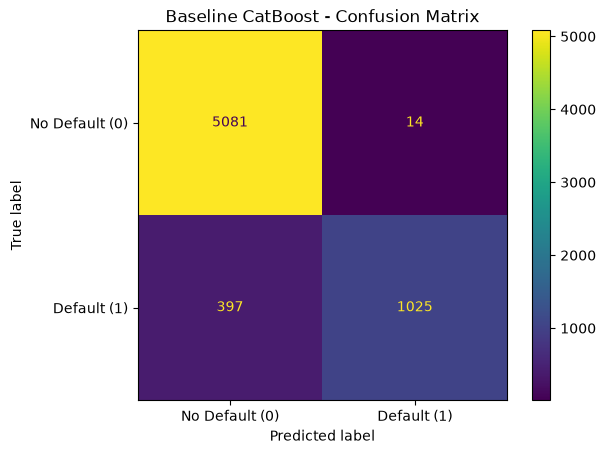

Confusion Matrix:
[[5081   14]
 [ 397 1025]]


In [11]:
# Cell 10: Confusion Matrix for baseline CatBoost model

cm_baseline = confusion_matrix(y_test, y_pred_baseline)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=["No Default (0)", "Default (1)"]
)

disp.plot(values_format="d")
plt.title("Baseline CatBoost - Confusion Matrix")
plt.show()

print("Confusion Matrix:")
print(cm_baseline)

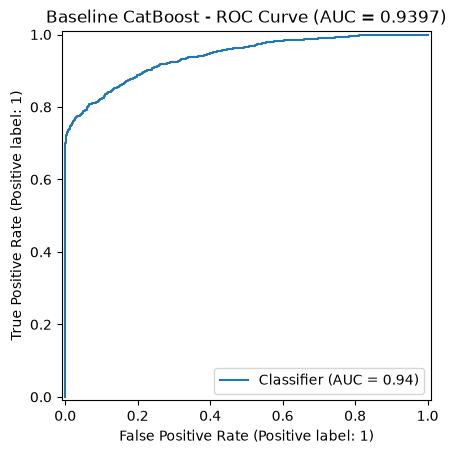

In [12]:
# Cell 11: ROC Curve for baseline CatBoost model

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_baseline
)

plt.title(f"Baseline CatBoost - ROC Curve (AUC = {baseline_roc_auc:.4f})")
plt.show()

In [13]:
# Cell 12: Train CatBoost Variant 2 with class balancing

balanced_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    auto_class_weights="Balanced",
    random_seed=RANDOM_STATE,
    verbose=False
)

balanced_model.fit(train_pool)

print("Balanced CatBoost model trained successfully.")

print("\nBalanced model parameters:")
print("Iterations:", balanced_model.get_param("iterations"))
print("Depth:", balanced_model.get_param("depth"))
print("Learning rate:", balanced_model.get_param("learning_rate"))
print("Class weights:", balanced_model.get_param("auto_class_weights"))

Balanced CatBoost model trained successfully.

Balanced model parameters:
Iterations: 300
Depth: 6
Learning rate: 0.05
Class weights: Balanced


In [14]:
# Cell 13: Evaluate balanced CatBoost model

# Predictions
y_pred_balanced = balanced_model.predict(test_pool)
y_prob_balanced = balanced_model.predict_proba(test_pool)[:, 1]

# Evaluation metrics
balanced_accuracy = accuracy_score(y_test, y_pred_balanced)
balanced_precision = precision_score(y_test, y_pred_balanced)
balanced_recall = recall_score(y_test, y_pred_balanced)
balanced_f1 = f1_score(y_test, y_pred_balanced)
balanced_roc_auc = roc_auc_score(y_test, y_prob_balanced)

print("Balanced CatBoost Evaluation")
print("-" * 35)

print(f"Accuracy : {balanced_accuracy:.4f}")
print(f"Precision: {balanced_precision:.4f}")
print(f"Recall   : {balanced_recall:.4f}")
print(f"F1 Score : {balanced_f1:.4f}")
print(f"ROC-AUC  : {balanced_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced, digits=4))

# Compare baseline vs balanced model
comparison_1 = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc_auc
    ],
    "Balanced": [
        balanced_accuracy,
        balanced_precision,
        balanced_recall,
        balanced_f1,
        balanced_roc_auc
    ]
})

print("\nBaseline vs Balanced CatBoost:")
display(comparison_1.round(4))

Balanced CatBoost Evaluation
-----------------------------------
Accuracy : 0.9208
Precision: 0.8523
Recall   : 0.7707
F1 Score : 0.8095
ROC-AUC  : 0.9410

Classification Report:
              precision    recall  f1-score   support

           0     0.9377    0.9627    0.9500      5095
           1     0.8523    0.7707    0.8095      1422

    accuracy                         0.9208      6517
   macro avg     0.8950    0.8667    0.8797      6517
weighted avg     0.9190    0.9208    0.9194      6517


Baseline vs Balanced CatBoost:


,Metric,Baseline,Balanced
0,Accuracy,0.9369,0.9208
1,Precision,0.9865,0.8523
2,Recall,0.7208,0.7707
3,F1 Score,0.8330,0.8095
4,ROC-AUC,0.9397,0.9410


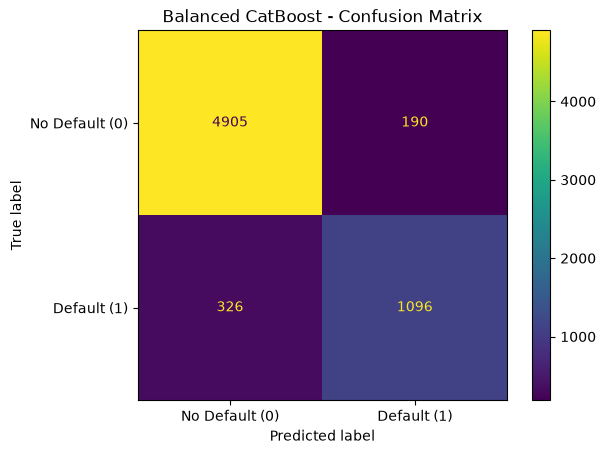

Balanced Model Confusion Matrix:
[[4905  190]
 [ 326 1096]]

False Negatives Comparison
Baseline false negatives: 397
Balanced false negatives: 326
Reduction in false negatives: 71


In [15]:
# Cell 14: Confusion Matrix for balanced CatBoost model

cm_balanced = confusion_matrix(y_test, y_pred_balanced)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=["No Default (0)", "Default (1)"]
)

disp.plot(values_format="d")
plt.title("Balanced CatBoost - Confusion Matrix")
plt.show()

print("Balanced Model Confusion Matrix:")
print(cm_balanced)

# Compare false negatives
baseline_fn = cm_baseline[1, 0]
balanced_fn = cm_balanced[1, 0]

print("\nFalse Negatives Comparison")
print("Baseline false negatives:", baseline_fn)
print("Balanced false negatives:", balanced_fn)
print("Reduction in false negatives:", baseline_fn - balanced_fn)

In [16]:
# Cell 15: Train CatBoost Variant 3 with deeper trees

deep_model = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.03,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False
)

deep_model.fit(train_pool)

print("Deep CatBoost model trained successfully.")

print("\nDeep model parameters:")
print("Iterations:", deep_model.get_param("iterations"))
print("Depth:", deep_model.get_param("depth"))
print("Learning rate:", deep_model.get_param("learning_rate"))

Deep CatBoost model trained successfully.

Deep model parameters:
Iterations: 500
Depth: 8
Learning rate: 0.03


In [17]:
# Cell 16: Evaluate deep CatBoost model and compare all three variants

# Predictions
y_pred_deep = deep_model.predict(test_pool)
y_prob_deep = deep_model.predict_proba(test_pool)[:, 1]

# Evaluation metrics
deep_accuracy = accuracy_score(y_test, y_pred_deep)
deep_precision = precision_score(y_test, y_pred_deep)
deep_recall = recall_score(y_test, y_pred_deep)
deep_f1 = f1_score(y_test, y_pred_deep)
deep_roc_auc = roc_auc_score(y_test, y_prob_deep)

print("Deep CatBoost Evaluation")
print("-" * 35)

print(f"Accuracy : {deep_accuracy:.4f}")
print(f"Precision: {deep_precision:.4f}")
print(f"Recall   : {deep_recall:.4f}")
print(f"F1 Score : {deep_f1:.4f}")
print(f"ROC-AUC  : {deep_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_deep, digits=4))

# Compare all three models
comparison_2 = pd.DataFrame({
    "Model": [
        "Baseline CatBoost",
        "Balanced CatBoost",
        "Deep CatBoost"
    ],
    "Accuracy": [
        baseline_accuracy,
        balanced_accuracy,
        deep_accuracy
    ],
    "Precision": [
        baseline_precision,
        balanced_precision,
        deep_precision
    ],
    "Recall": [
        baseline_recall,
        balanced_recall,
        deep_recall
    ],
    "F1 Score": [
        baseline_f1,
        balanced_f1,
        deep_f1
    ],
    "ROC-AUC": [
        baseline_roc_auc,
        balanced_roc_auc,
        deep_roc_auc
    ]
})

print("\nCatBoost Variant Comparison:")
display(comparison_2.round(4))

Deep CatBoost Evaluation
-----------------------------------
Accuracy : 0.9374
Precision: 0.9856
Recall   : 0.7236
F1 Score : 0.8345
ROC-AUC  : 0.9410

Classification Report:
              precision    recall  f1-score   support

           0     0.9282    0.9971    0.9614      5095
           1     0.9856    0.7236    0.8345      1422

    accuracy                         0.9374      6517
   macro avg     0.9569    0.8603    0.8980      6517
weighted avg     0.9407    0.9374    0.9337      6517


CatBoost Variant Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline CatBoost,0.9369,0.9865,0.7208,0.8330,0.9397
1,Balanced CatBoost,0.9208,0.8523,0.7707,0.8095,0.9410
2,Deep CatBoost,0.9374,0.9856,0.7236,0.8345,0.9410


In [18]:
# Cell 17: Hyperparameter tuning using CatBoost randomized search
# IMPORTANT: tuning is performed only on the training data

param_distributions = {
    "iterations": [300, 400, 500, 600],
    "depth": [5, 6, 7, 8],
    "learning_rate": [0.02, 0.03, 0.05, 0.08],
    "l2_leaf_reg": [3, 5, 7, 9]
}

tuned_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=RANDOM_STATE,
    verbose=False
)

tuning_results = tuned_model.randomized_search(
    param_distributions,
    X=train_pool,
    n_iter=8,
    cv=3,
    stratified=True,
    partition_random_seed=RANDOM_STATE,
    refit=True,
    verbose=False,
    plot=False
)

best_params = tuning_results["params"]

print("Hyperparameter tuning completed successfully.")

print("\nBest parameters:")
for parameter, value in best_params.items():
    print(f"{parameter}: {value}")


bestTest = 0.821559393
bestIteration = 171


bestTest = 0.8192771084
bestIteration = 568


bestTest = 0.819466248
bestIteration = 494


bestTest = 0.8208877285
bestIteration = 237


bestTest = 0.822303283
bestIteration = 331


bestTest = 0.820083682
bestIteration = 511


bestTest = 0.8245067497
bestIteration = 493


bestTest = 0.8221757322
bestIteration = 471

Training on fold [0/3]

bestTest = 0.8394537178
bestIteration = 406

Training on fold [1/3]

bestTest = 0.8461077844
bestIteration = 338

Training on fold [2/3]

bestTest = 0.8273556231
bestIteration = 427

Hyperparameter tuning completed successfully.

Best parameters:
depth: 8
learning_rate: 0.08
l2_leaf_reg: 5
iterations: 500


In [19]:
# Cell 18: Evaluate tuned CatBoost model

# Predictions from the tuned model
y_pred_tuned = tuned_model.predict(test_pool)
y_prob_tuned = tuned_model.predict_proba(test_pool)[:, 1]

# Evaluation metrics
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)
tuned_roc_auc = roc_auc_score(y_test, y_prob_tuned)

print("Tuned CatBoost Evaluation")
print("-" * 35)

print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1 Score : {tuned_f1:.4f}")
print(f"ROC-AUC  : {tuned_roc_auc:.4f}")

print("\nBest Hyperparameters:")
for parameter, value in best_params.items():
    print(f"{parameter}: {value}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, digits=4))

# Compare all four versions
comparison_3 = pd.DataFrame({
    "Model": [
        "Baseline CatBoost",
        "Balanced CatBoost",
        "Deep CatBoost",
        "Tuned CatBoost"
    ],
    "Accuracy": [
        baseline_accuracy,
        balanced_accuracy,
        deep_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        baseline_precision,
        balanced_precision,
        deep_precision,
        tuned_precision
    ],
    "Recall": [
        baseline_recall,
        balanced_recall,
        deep_recall,
        tuned_recall
    ],
    "F1 Score": [
        baseline_f1,
        balanced_f1,
        deep_f1,
        tuned_f1
    ],
    "ROC-AUC": [
        baseline_roc_auc,
        balanced_roc_auc,
        deep_roc_auc,
        tuned_roc_auc
    ]
})

print("\nFinal CatBoost Variant Comparison:")
display(comparison_3.round(4))

Tuned CatBoost Evaluation
-----------------------------------
Accuracy : 0.9374
Precision: 0.9819
Recall   : 0.7264
F1 Score : 0.8351
ROC-AUC  : 0.9490

Best Hyperparameters:
depth: 8
learning_rate: 0.08
l2_leaf_reg: 5
iterations: 500

Classification Report:
              precision    recall  f1-score   support

           0     0.9288    0.9963    0.9614      5095
           1     0.9819    0.7264    0.8351      1422

    accuracy                         0.9374      6517
   macro avg     0.9554    0.8614    0.8982      6517
weighted avg     0.9404    0.9374    0.9338      6517


Final CatBoost Variant Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline CatBoost,0.9369,0.9865,0.7208,0.8330,0.9397
1,Balanced CatBoost,0.9208,0.8523,0.7707,0.8095,0.9410
2,Deep CatBoost,0.9374,0.9856,0.7236,0.8345,0.9410
3,Tuned CatBoost,0.9374,0.9819,0.7264,0.8351,0.9490


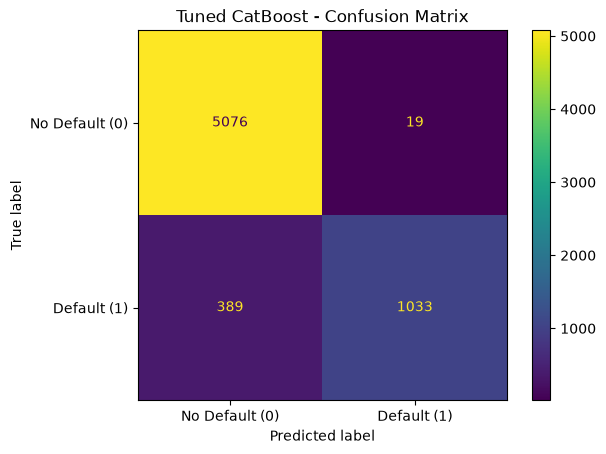

Tuned Model Confusion Matrix:
[[5076   19]
 [ 389 1033]]

False Negative Comparison
Baseline CatBoost : 397
Balanced CatBoost : 326
Tuned CatBoost    : 389


In [20]:
# Cell 19: Confusion Matrix for tuned CatBoost model

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["No Default (0)", "Default (1)"]
)

disp.plot(values_format="d")
plt.title("Tuned CatBoost - Confusion Matrix")
plt.show()

print("Tuned Model Confusion Matrix:")
print(cm_tuned)

# Compare false negatives across models
baseline_fn = cm_baseline[1, 0]
balanced_fn = cm_balanced[1, 0]
tuned_fn = cm_tuned[1, 0]

print("\nFalse Negative Comparison")
print("Baseline CatBoost :", baseline_fn)
print("Balanced CatBoost :", balanced_fn)
print("Tuned CatBoost    :", tuned_fn)

<Figure size 800x600 with 0 Axes>

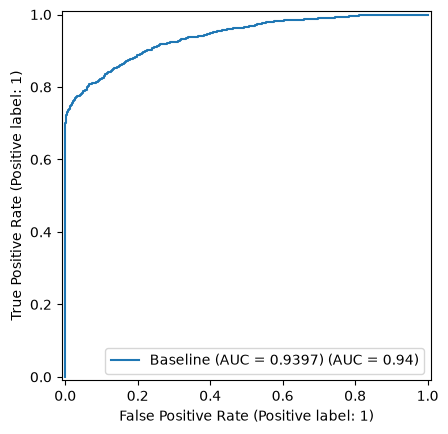

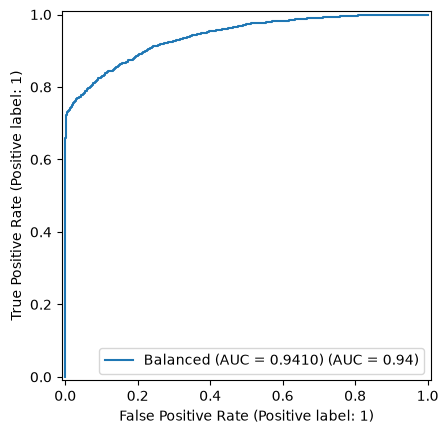

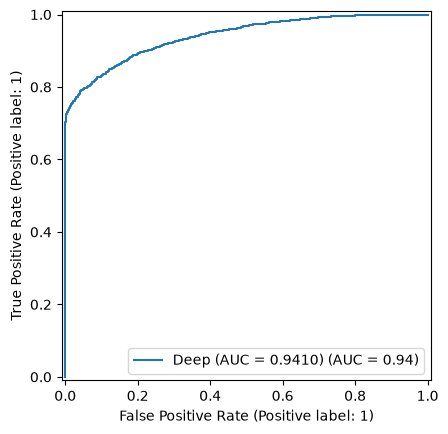

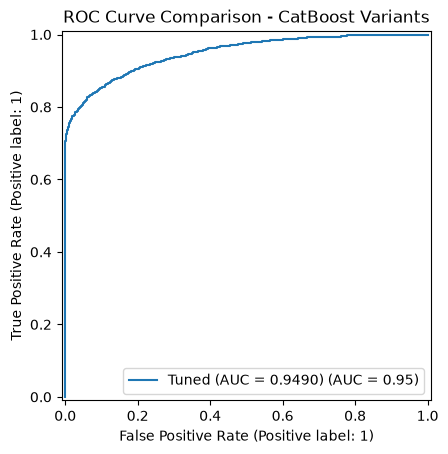

In [21]:
# Cell 20: Compare ROC curves for all CatBoost variants

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_baseline,
    name=f"Baseline (AUC = {baseline_roc_auc:.4f})"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_balanced,
    name=f"Balanced (AUC = {balanced_roc_auc:.4f})"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_deep,
    name=f"Deep (AUC = {deep_roc_auc:.4f})"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_tuned,
    name=f"Tuned (AUC = {tuned_roc_auc:.4f})"
)

plt.title("ROC Curve Comparison - CatBoost Variants")
plt.show()

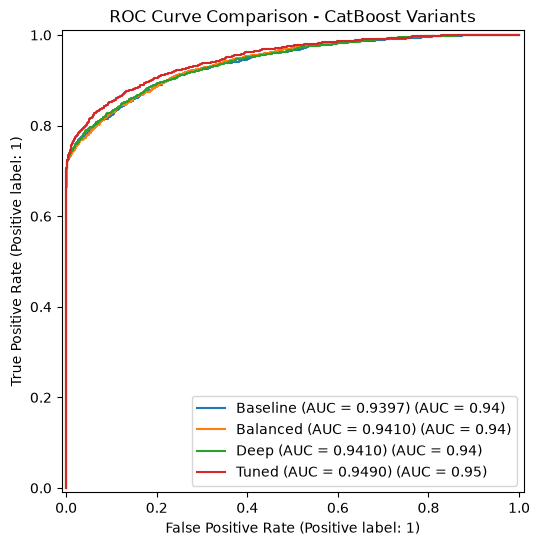

In [22]:
# Cell 20: Compare ROC curves for all CatBoost variants

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_baseline,
    name=f"Baseline (AUC = {baseline_roc_auc:.4f})",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_balanced,
    name=f"Balanced (AUC = {balanced_roc_auc:.4f})",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_deep,
    name=f"Deep (AUC = {deep_roc_auc:.4f})",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_tuned,
    name=f"Tuned (AUC = {tuned_roc_auc:.4f})",
    ax=ax
)

ax.set_title("ROC Curve Comparison - CatBoost Variants")
plt.show()

Feature Importance - Tuned CatBoost


,Feature,Importance
8,loan_percent_income,22.5821
2,person_home_ownership,15.3501
1,person_income,14.6691
5,loan_grade,14.3156
4,loan_intent,12.5415
3,person_emp_length,6.5782
7,loan_int_rate,4.0354
6,loan_amnt,3.8709
0,person_age,3.6940
10,cb_person_cred_hist_length,1.8786


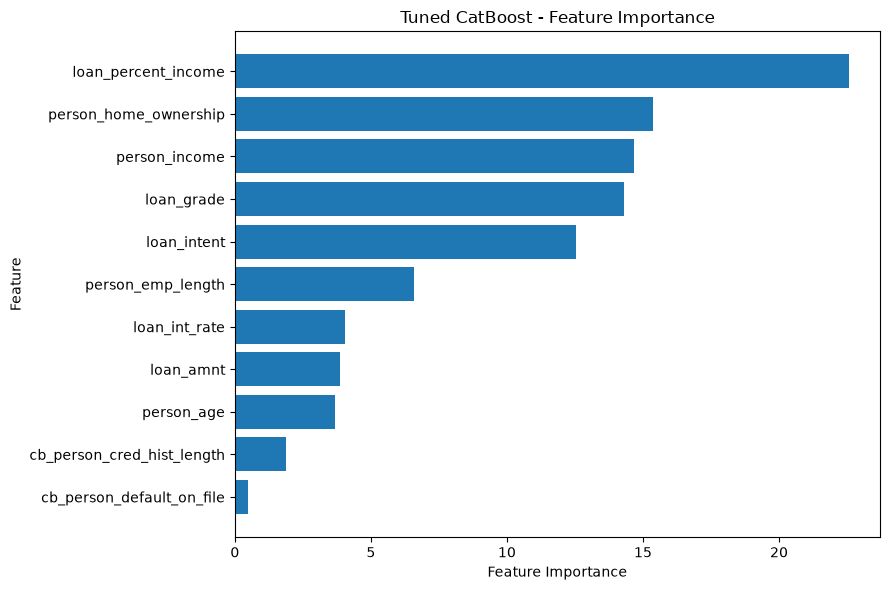

In [23]:
# Cell 21: Feature importance of tuned CatBoost model

feature_importance = tuned_model.get_feature_importance(train_pool)

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

print("Feature Importance - Tuned CatBoost")
display(importance_df.round(4))

# Plot feature importance
plt.figure(figsize=(9, 6))

plt.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Tuned CatBoost - Feature Importance")
plt.tight_layout()
plt.show()

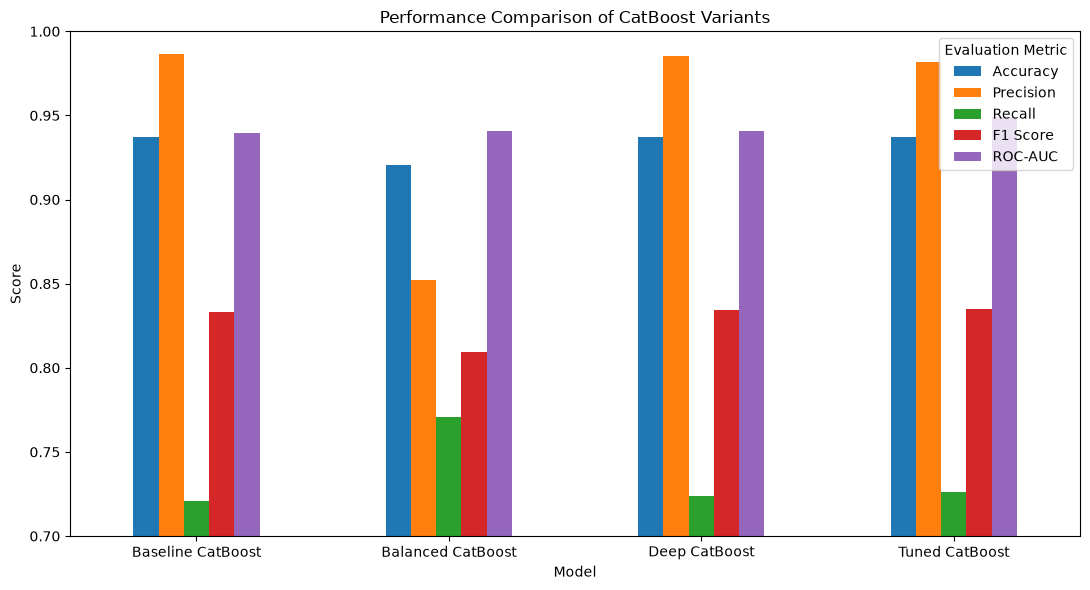

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline CatBoost,0.9369,0.9865,0.7208,0.8330,0.9397
1,Balanced CatBoost,0.9208,0.8523,0.7707,0.8095,0.9410
2,Deep CatBoost,0.9374,0.9856,0.7236,0.8345,0.9410
3,Tuned CatBoost,0.9374,0.9819,0.7264,0.8351,0.9490


In [24]:
# Cell 22: Visual comparison of all CatBoost variants

comparison_plot = comparison_3.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Performance Comparison of CatBoost Variants")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0.70, 1.00)
plt.xticks(rotation=0)
plt.legend(title="Evaluation Metric")
plt.tight_layout()
plt.show()

# Display the exact values again
display(comparison_3.round(4))

In [25]:
# Cell 23: Identify the best CatBoost configuration

best_f1_row = comparison_3.loc[comparison_3["F1 Score"].idxmax()]
best_auc_row = comparison_3.loc[comparison_3["ROC-AUC"].idxmax()]
best_recall_row = comparison_3.loc[comparison_3["Recall"].idxmax()]

print("FINAL CATBOOST MODEL ANALYSIS")
print("=" * 45)

print("\nHighest F1 Score:")
print(f"Model    : {best_f1_row['Model']}")
print(f"F1 Score : {best_f1_row['F1 Score']:.4f}")

print("\nHighest ROC-AUC:")
print(f"Model    : {best_auc_row['Model']}")
print(f"ROC-AUC  : {best_auc_row['ROC-AUC']:.4f}")

print("\nHighest Recall:")
print(f"Model    : {best_recall_row['Model']}")
print(f"Recall   : {best_recall_row['Recall']:.4f}")

print("\nSelected Final Model: Tuned CatBoost")

print("\nBest Hyperparameters:")
for parameter, value in best_params.items():
    print(f"{parameter}: {value}")

print("\nFinal Test Performance:")
print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1 Score : {tuned_f1:.4f}")
print(f"ROC-AUC  : {tuned_roc_auc:.4f}")

print("\nConclusion:")
print(
    "The Tuned CatBoost model was selected as the final model because "
    "it achieved the highest F1-score and ROC-AUC among the tested "
    "CatBoost configurations. The Balanced CatBoost model achieved "
    "the highest recall, showing that class balancing improved the "
    "detection of default cases, but this reduced precision and overall accuracy."
)

FINAL CATBOOST MODEL ANALYSIS

Highest F1 Score:
Model    : Tuned CatBoost
F1 Score : 0.8351

Highest ROC-AUC:
Model    : Tuned CatBoost
ROC-AUC  : 0.9490

Highest Recall:
Model    : Balanced CatBoost
Recall   : 0.7707

Selected Final Model: Tuned CatBoost

Best Hyperparameters:
depth: 8
learning_rate: 0.08
l2_leaf_reg: 5
iterations: 500

Final Test Performance:
Accuracy : 0.9374
Precision: 0.9819
Recall   : 0.7264
F1 Score : 0.8351
ROC-AUC  : 0.9490

Conclusion:
The Tuned CatBoost model was selected as the final model because it achieved the highest F1-score and ROC-AUC among the tested CatBoost configurations. The Balanced CatBoost model achieved the highest recall, showing that class balancing improved the detection of default cases, but this reduced precision and overall accuracy.


In [26]:
# Cell 24: 5-Fold Cross-Validation for the tuned CatBoost model

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):

    # Create fold training and validation sets
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Create CatBoost Pool objects
    fold_train_pool = Pool(
        X_fold_train,
        y_fold_train,
        cat_features=categorical_features
    )

    fold_val_pool = Pool(
        X_fold_val,
        y_fold_val,
        cat_features=categorical_features
    )

    # Create model using the best tuned parameters
    cv_model = CatBoostClassifier(
        **best_params,
        loss_function="Logloss",
        random_seed=RANDOM_STATE,
        verbose=False
    )

    # Train model
    cv_model.fit(fold_train_pool)

    # Predictions
    fold_pred = cv_model.predict(fold_val_pool)
    fold_prob = cv_model.predict_proba(fold_val_pool)[:, 1]

    # Calculate metrics
    fold_accuracy = accuracy_score(y_fold_val, fold_pred)
    fold_precision = precision_score(y_fold_val, fold_pred)
    fold_recall = recall_score(y_fold_val, fold_pred)
    fold_f1 = f1_score(y_fold_val, fold_pred)
    fold_auc = roc_auc_score(y_fold_val, fold_prob)

    cv_results.append({
        "Fold": fold,
        "Accuracy": fold_accuracy,
        "Precision": fold_precision,
        "Recall": fold_recall,
        "F1 Score": fold_f1,
        "ROC-AUC": fold_auc
    })

# Convert results to DataFrame
cv_results_df = pd.DataFrame(cv_results)

print("5-Fold Cross-Validation Results:")
display(cv_results_df.round(4))

print("\nMean Cross-Validation Performance:")
print(f"Accuracy : {cv_results_df['Accuracy'].mean():.4f} ± {cv_results_df['Accuracy'].std():.4f}")
print(f"Precision: {cv_results_df['Precision'].mean():.4f} ± {cv_results_df['Precision'].std():.4f}")
print(f"Recall   : {cv_results_df['Recall'].mean():.4f} ± {cv_results_df['Recall'].std():.4f}")
print(f"F1 Score : {cv_results_df['F1 Score'].mean():.4f} ± {cv_results_df['F1 Score'].std():.4f}")
print(f"ROC-AUC  : {cv_results_df['ROC-AUC'].mean():.4f} ± {cv_results_df['ROC-AUC'].std():.4f}")

5-Fold Cross-Validation Results:


,Fold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1,0.9428,0.9850,0.7493,0.8511,0.9454
1,2,0.9403,0.9758,0.7449,0.8449,0.9442
2,3,0.9325,0.9678,0.7142,0.8219,0.9352
3,4,0.9367,0.9867,0.7197,0.8323,0.9393
4,5,0.9338,0.9703,0.7186,0.8257,0.9423



Mean Cross-Validation Performance:
Accuracy : 0.9372 ± 0.0044
Precision: 0.9771 ± 0.0085
Recall   : 0.7293 ± 0.0165
F1 Score : 0.8352 ± 0.0125
ROC-AUC  : 0.9413 ± 0.0041


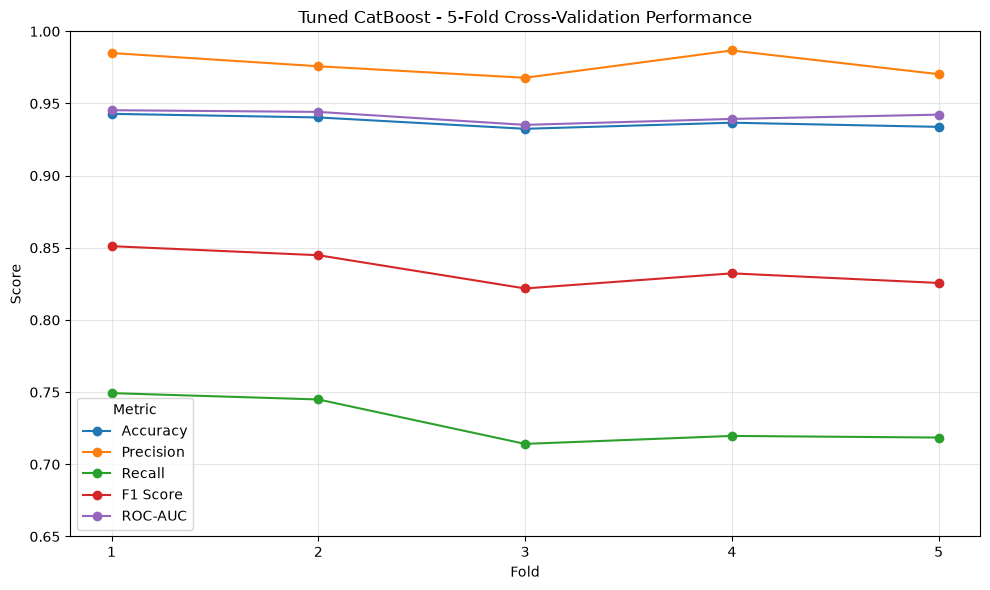

Cross-Validation Summary:


,Mean,Std Dev
Accuracy,0.9372,0.0044
Precision,0.9771,0.0085
Recall,0.7293,0.0165
F1 Score,0.8352,0.0125
ROC-AUC,0.9413,0.0041


In [27]:
# Cell 25: Visualize 5-fold cross-validation performance

cv_plot_df = cv_results_df.set_index("Fold")

cv_plot_df.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Tuned CatBoost - 5-Fold Cross-Validation Performance")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.ylim(0.65, 1.00)
plt.xticks(cv_results_df["Fold"])
plt.grid(alpha=0.3)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# Display mean and standard deviation
cv_summary = pd.DataFrame({
    "Mean": cv_results_df.drop(columns="Fold").mean(),
    "Std Dev": cv_results_df.drop(columns="Fold").std()
})

print("Cross-Validation Summary:")
display(cv_summary.round(4))

## Limitations and Possible Improvements

### Limitations

1. **Class Imbalance**  
   The target variable is imbalanced, with approximately 78.18% non-default cases and 21.82% default cases. Although the tuned CatBoost model achieved strong overall performance, recall for the default class was lower than precision.

2. **False Negatives**  
   The tuned model still produced 389 false negatives. These represent actual default cases that were predicted as non-default, which can be important in a credit-risk application.

3. **Limited Hyperparameter Search**  
   Randomized hyperparameter tuning was performed using a selected range of parameters and eight combinations. Therefore, other parameter combinations may produce better performance.

4. **Single Dataset**  
   The model was trained and evaluated using one credit-risk dataset. Performance may differ when applied to data from another institution, country, time period, or customer population.

5. **Missing Values**  
   The dataset contains missing numerical values, such as missing values in `person_emp_length`. CatBoost can handle numerical missing values internally, but alternative imputation techniques could also be investigated.

6. **Feature Importance Does Not Show Causation**  
   CatBoost feature importance shows which variables influenced predictions, but it does not prove that those features directly cause loan default.

### Possible Improvements

- Test a wider range of CatBoost hyperparameters and perform a larger randomized or grid search.
- Investigate different class-weight settings to improve recall while maintaining strong precision.
- Experiment with decision-threshold tuning instead of using only the default classification threshold.
- Compare different missing-value treatment strategies.
- Use additional or more recent credit-risk datasets to test model generalization.
- Apply explainability techniques such as SHAP values to better understand individual predictions.
- Investigate fairness and potential bias across relevant groups before using the model in a real lending environment.

## Final Model Summary and Reflection

Four CatBoost configurations were evaluated in this notebook:

- Baseline CatBoost
- Balanced CatBoost
- Deep CatBoost
- Tuned CatBoost

The Tuned CatBoost model achieved the strongest overall performance.

### Final Tuned CatBoost Performance

- **Accuracy:** 0.9374
- **Precision:** 0.9819
- **Recall:** 0.7264
- **F1-score:** 0.8351
- **ROC-AUC:** 0.9490

### Best Hyperparameters

- `iterations = 500`
- `depth = 8`
- `learning_rate = 0.08`
- `l2_leaf_reg = 5`

The tuned model achieved the highest F1-score and ROC-AUC among the tested configurations.

The Balanced CatBoost model achieved the highest recall of **0.7707** and reduced false negatives from **397 to 326**. However, this improvement in recall resulted in lower precision and accuracy.

The 5-fold cross-validation results for the tuned model were:

- **Mean Accuracy:** 0.9372 ± 0.0044
- **Mean Precision:** 0.9771 ± 0.0085
- **Mean Recall:** 0.7293 ± 0.0165
- **Mean F1-score:** 0.8352 ± 0.0125
- **Mean ROC-AUC:** 0.9413 ± 0.0041

The similarity between the cross-validation results and the held-out test results suggests that the model performs consistently across different subsets of the data.

### Reflection

This experiment showed that hyperparameter tuning improved CatBoost's overall predictive performance, especially ROC-AUC. It also demonstrated that improving one metric can affect another. For example, class balancing improved recall and reduced false negatives, but decreased precision and accuracy.

CatBoost was suitable for this dataset because it handled the categorical features directly and could also work with missing numerical values without requiring extensive preprocessing.

Overall, the Tuned CatBoost model was selected as the final configuration because it provided the strongest overall balance of F1-score, ROC-AUC, accuracy, and precision.

In [28]:
# Cell 28: Save CatBoost results for group integration

import json

# Create output directory
RESULT_DIR = PROJECT_ROOT / "results" / "model_results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save comparison of all CatBoost variants
comparison_3.to_csv(
    RESULT_DIR / "IT25102123_CatBoost_Model_Comparison.csv",
    index=False
)

# 2. Save 5-fold cross-validation results
cv_results_df.to_csv(
    RESULT_DIR / "IT25102123_CatBoost_CrossValidation.csv",
    index=False
)

# 3. Save feature importance
importance_df.to_csv(
    RESULT_DIR / "IT25102123_CatBoost_Feature_Importance.csv",
    index=False
)

# 4. Save best hyperparameters
with open(
    RESULT_DIR / "IT25102123_CatBoost_Best_Parameters.json",
    "w"
) as file:
    json.dump(best_params, file, indent=4)

# 5. Save trained tuned CatBoost model
tuned_model.save_model(
    str(RESULT_DIR / "IT25102123_Tuned_CatBoost_Model.cbm")
)

print("CatBoost results saved successfully.")
print("\nSaved files:")

for file in sorted(RESULT_DIR.glob("IT25102123*")):
    print("-", file.name)

CatBoost results saved successfully.

Saved files:
- IT25102123_CatBoost_Best_Parameters.json
- IT25102123_CatBoost_CrossValidation.csv
- IT25102123_CatBoost_Feature_Importance.csv
- IT25102123_CatBoost_Model_Comparison.csv
- IT25102123_Tuned_CatBoost_Model.cbm


In [29]:
# Cell 29: Save optimum CatBoost result for final group comparison

COMPARISON_DIR = PROJECT_ROOT / "results" / "model_comparison"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

final_catboost_result = pd.DataFrame([{
    "Student_ID": "IT25102123",
    "Model": "CatBoost",
    "Selected_Variant": "Tuned CatBoost",

    "Accuracy": tuned_accuracy,
    "Precision": tuned_precision,
    "Recall": tuned_recall,
    "F1_Score": tuned_f1,
    "ROC_AUC": tuned_roc_auc,

    "False_Negatives": int(cm_tuned[1, 0]),

    "CV_Mean_Accuracy": cv_results_df["Accuracy"].mean(),
    "CV_Mean_Precision": cv_results_df["Precision"].mean(),
    "CV_Mean_Recall": cv_results_df["Recall"].mean(),
    "CV_Mean_F1": cv_results_df["F1 Score"].mean(),
    "CV_Mean_ROC_AUC": cv_results_df["ROC-AUC"].mean(),

    "Best_Iterations": best_params["iterations"],
    "Best_Depth": best_params["depth"],
    "Best_Learning_Rate": best_params["learning_rate"],
    "Best_L2_Leaf_Reg": best_params["l2_leaf_reg"]
}])

final_result_path = (
    COMPARISON_DIR /
    "IT25102123_CatBoost_Final_Result.csv"
)

final_catboost_result.to_csv(
    final_result_path,
    index=False
)

print("Final CatBoost result saved successfully.")
print("\nFile:")
print(final_result_path)

print("\nFinal result for group comparison:")
display(final_catboost_result.round(4))

Final CatBoost result saved successfully.

File:
D:\2026-Y2-S1-MET-18\results\model_comparison\IT25102123_CatBoost_Final_Result.csv

Final result for group comparison:


,Student_ID,Model,Selected_Variant,Accuracy,Precision,Recall,F1_Score,ROC_AUC,False_Negatives,CV_Mean_Accuracy,CV_Mean_Precision,CV_Mean_Recall,CV_Mean_F1,CV_Mean_ROC_AUC,Best_Iterations,Best_Depth,Best_Learning_Rate,Best_L2_Leaf_Reg
0,IT25102123,CatBoost,Tuned CatBoost,0.9374,0.9819,0.7264,0.8351,0.949,389,0.9372,0.9771,0.7293,0.8352,0.9413,500,8,0.08,5


In [30]:
# Cell 30: Final verification checklist

print("IT25102123 - CATBOOST FINAL CHECKLIST")
print("=" * 50)

checks = {
    "Dataset loaded": "df" in globals(),
    "Target defined": "TARGET" in globals(),
    "Train/test split created": all(
        name in globals()
        for name in ["X_train", "X_test", "y_train", "y_test"]
    ),
    "Categorical features identified": "categorical_features" in globals(),
    "CatBoost Pool created": all(
        name in globals()
        for name in ["train_pool", "test_pool"]
    ),
    "Baseline model trained": "baseline_model" in globals(),
    "Balanced model trained": "balanced_model" in globals(),
    "Deep model trained": "deep_model" in globals(),
    "Hyperparameter tuning completed": "best_params" in globals(),
    "Tuned model available": "tuned_model" in globals(),
    "Confusion matrix calculated": "cm_tuned" in globals(),
    "Feature importance calculated": "importance_df" in globals(),
    "5-fold cross-validation completed": "cv_results_df" in globals(),
    "Model comparison created": "comparison_3" in globals(),
    "Final group result created": "final_catboost_result" in globals(),
}

all_passed = True

for item, status in checks.items():
    symbol = "PASS" if status else "FAIL"
    print(f"{symbol:4} | {item}")

    if not status:
        all_passed = False

print("\n" + "=" * 50)

if all_passed:
    print("ALL CHECKS PASSED")
    print("CatBoost implementation is complete.")
else:
    print("Some checks failed. Review the cells above.")

print("\nFINAL SELECTED MODEL")
print("-" * 30)
print("Student ID : IT25102123")
print("Model      : CatBoost")
print("Variant    : Tuned CatBoost")

print("\nBest Parameters:")
print(f"Iterations    : {best_params['iterations']}")
print(f"Depth         : {best_params['depth']}")
print(f"Learning Rate : {best_params['learning_rate']}")
print(f"L2 Leaf Reg   : {best_params['l2_leaf_reg']}")

print("\nFinal Test Results:")
print(f"Accuracy  : {tuned_accuracy:.4f}")
print(f"Precision : {tuned_precision:.4f}")
print(f"Recall    : {tuned_recall:.4f}")
print(f"F1 Score  : {tuned_f1:.4f}")
print(f"ROC-AUC   : {tuned_roc_auc:.4f}")

print("\n5-Fold CV Results:")
print(f"Mean Accuracy : {cv_results_df['Accuracy'].mean():.4f}")
print(f"Mean F1       : {cv_results_df['F1 Score'].mean():.4f}")
print(f"Mean ROC-AUC  : {cv_results_df['ROC-AUC'].mean():.4f}")

print("\nSaved group result:")
print(final_result_path)

IT25102123 - CATBOOST FINAL CHECKLIST
PASS | Dataset loaded
PASS | Target defined
PASS | Train/test split created
PASS | Categorical features identified
PASS | CatBoost Pool created
PASS | Baseline model trained
PASS | Balanced model trained
PASS | Deep model trained
PASS | Hyperparameter tuning completed
PASS | Tuned model available
PASS | Confusion matrix calculated
PASS | Feature importance calculated
PASS | 5-fold cross-validation completed
PASS | Model comparison created
PASS | Final group result created

ALL CHECKS PASSED
CatBoost implementation is complete.

FINAL SELECTED MODEL
------------------------------
Student ID : IT25102123
Model      : CatBoost
Variant    : Tuned CatBoost

Best Parameters:
Iterations    : 500
Depth         : 8
Learning Rate : 0.08
L2 Leaf Reg   : 5

Final Test Results:
Accuracy  : 0.9374
Precision : 0.9819
Recall    : 0.7264
F1 Score  : 0.8351
ROC-AUC   : 0.9490

5-Fold CV Results:
Mean Accuracy : 0.9372
Mean F1       : 0.8352
Mean ROC-AUC  : 0.9413

S